In [ ]:
# connect google drive to colab

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# load data into pandas

import pandas as pd
from IPython.display import display
df=pd.read_csv("/content/drive/MyDrive/hackaton/data/raw_data/track4_sensor_data_dataset.csv")
print(f"\n The first 5 rows of data are {display(df.head())}")
print(f"\n The no of sensor data are {df.shape[0]}")
print(f"\n The no of columns are {df.shape[1]}")
print(f"\n Summary charecteristics are {display(df.describe())}")
print(f"\n The no of missing entry information are {display(df.isnull().sum())}")
print(f"\n The duplicate entry information if any can be checked here as {display(df.duplicated())}")
print(f"\n The count of duplicate entry information if any can be checked here as {df.duplicated().sum()}")



,timestamp,temperature,vibration,pressure,rotation_speed,power_consumption,anomaly
0,2026-02-24 11:14:25.091904,83.32,5.18,118.47,1460.0,59.89,0
1,2026-02-24 11:15:25.091904,82.92,6.87,101.81,1541.0,53.48,0
2,2026-02-24 11:16:25.091904,89.40,7.77,117.47,1434.7,48.99,0
3,2026-02-24 11:17:25.091904,88.65,4.78,112.68,1421.3,54.37,0
4,2026-02-24 11:18:25.091904,81.74,6.57,135.94,1503.1,57.21,0



 The first 5 rows of data are None

 The no of sensor data are 43200

 The no of columns are 7


,temperature,vibration,pressure,rotation_speed,power_consumption,anomaly
count,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000,43200.000000
mean,80.568272,5.181671,119.278606,1495.788398,50.373836,0.033773
std,7.329909,2.058189,11.994495,63.977966,6.704641,0.180647
min,52.370000,-1.500000,26.020000,982.600000,22.900000,0.000000
25%,76.110000,4.017500,112.880000,1463.800000,46.530000,0.000000
50%,80.140000,5.050000,119.840000,1499.000000,50.060000,0.000000
75%,84.250000,6.110000,126.630000,1533.800000,53.620000,0.000000
max,141.700000,26.710000,164.940000,1847.300000,116.290000,1.000000



 Summary charecteristics are None


,0
timestamp,0
temperature,0
vibration,0
pressure,0
rotation_speed,0
power_consumption,0
anomaly,0



 The no of missing entry information are None


,0
0,False
1,False
2,False
3,False
4,False
...,...
43195,False
43196,False
43197,False
43198,False



 The duplicate entry information if any can be checked here as None

 The count of duplicate entry information if any can be checked here as 0


In [ ]:
#EDA



# convert time stamo to datetime format

df['timestamp']=pd.to_datetime(df['timestamp'])
df.dtypes


,0
timestamp,datetime64[ns]
temperature,float64
vibration,float64
pressure,float64
rotation_speed,float64
power_consumption,float64
anomaly,int64


In [ ]:
#EDA

df=df.sort_values(by='timestamp',ascending=True)


In [ ]:
df.dtypes

,0
timestamp,datetime64[ns]
temperature,float64
vibration,float64
pressure,float64
rotation_speed,float64
power_consumption,float64
anomaly,int64


In [ ]:
df.index.to_series().diff().value_counts()

# tell the sesor are recorder every 1 min.
#.index give index of datframe . convert to series and compytes difference bwteen consecutve value of time stamp and give count of those


,count
1.0,43199


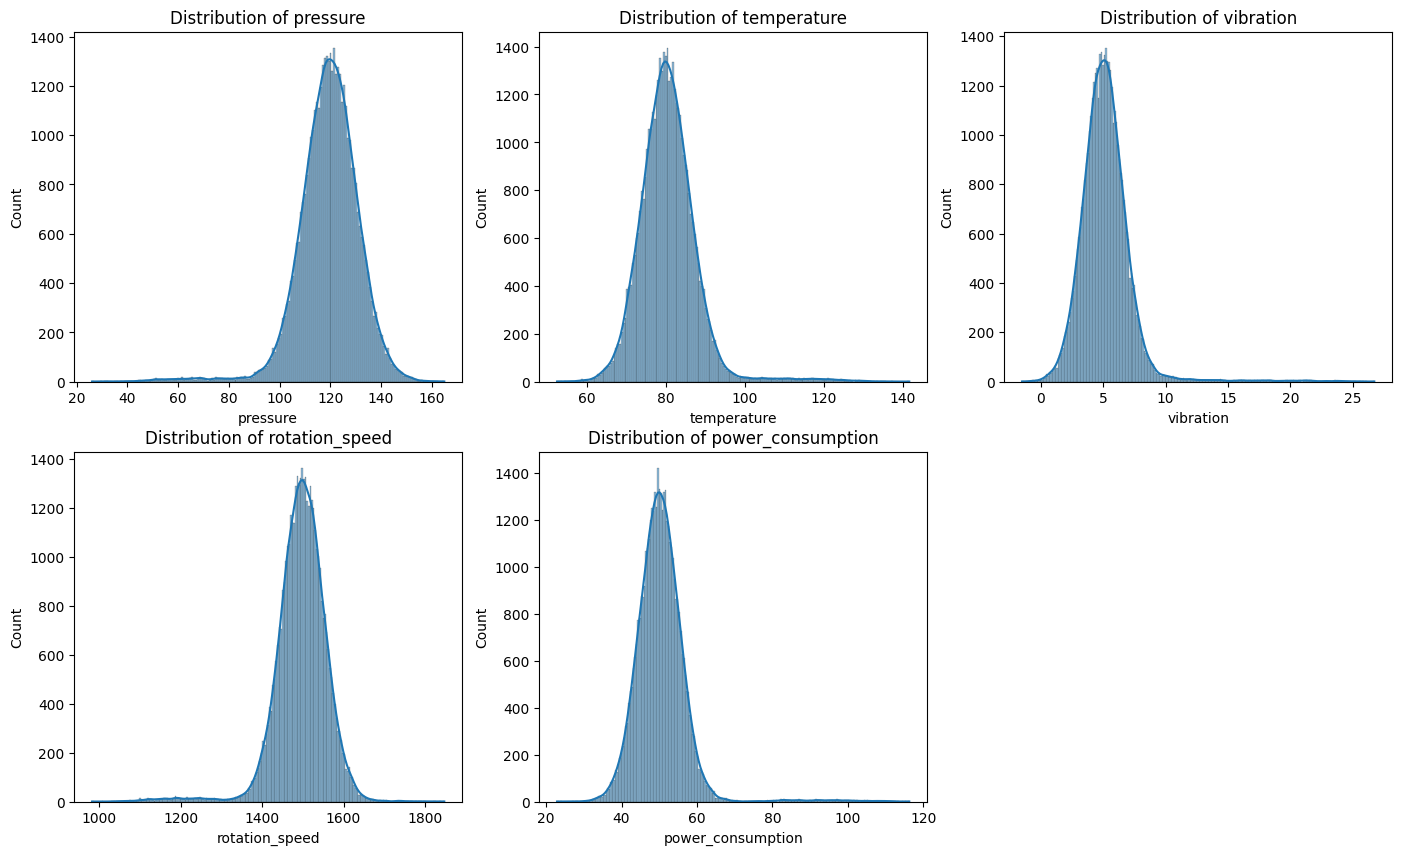

In [ ]:
# univariate analysis of each sensor data


import matplotlib.pyplot as plt
import seaborn as sns

columns=['pressure','temperature','vibration','rotation_speed','power_consumption']

plt.figure(figsize=(17,10))
for i,col in enumerate(columns):
  plt.subplot(2,3,i+1)
  sns.histplot(df[col],kde=True)
  plt.title(f'Distribution of {col}')
  plt.xlabel(f"{col}")
  plt.ylabel("Count")
plt.show()


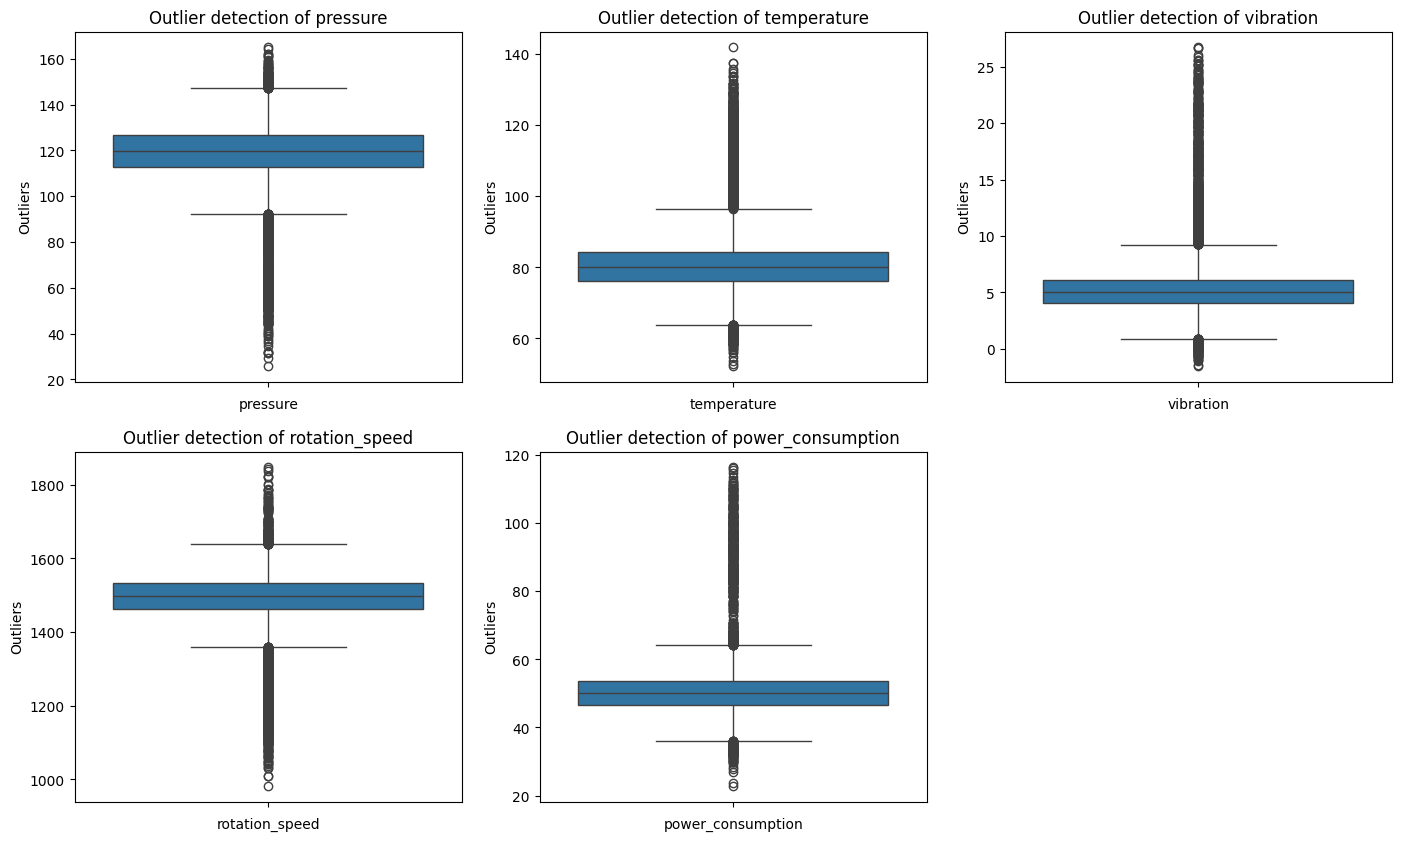

In [ ]:
plt.figure(figsize=(17,10))
for i,col in enumerate(columns):
  plt.subplot(2,3,i+1)
  sns.boxplot(df[col])
  plt.title(f"Outlier detection of {col}")
  plt.xlabel(f"{col}")
  plt.ylabel("Outliers")
plt.show()

# The histogram and box plot tells pressure, rotation speed are left sqewed ie lower value p <80 and N<1400 are possible anomalies or outlier to be flagged by model

# temp,vibration and power are right squewed ie T>100,power >60,vib>10 are anamllies sensor data posisble overheating excessive vibartion which lead to more power consumption

In [ ]:
df[df['pressure']<80]['anomaly'].value_counts()

# values <80 shows in  box plots are the anmolies

,count
anomaly,
1,480
0,4


In [ ]:
df[df['vibration']>10]['anomaly'].value_counts()

,count
anomaly,
1,640
0,32


In [ ]:
df[df['vibration']<2]['anomaly'].value_counts()
# vibration<2 are non anolamies mostly.

,count
anomaly,
0,1109
1,8


In [ ]:
df[df['temperature']>100]['anomaly'].value_counts()

,count
anomaly,
1,647
0,36


In [ ]:
df[df['temperature']<60]['anomaly'].value_counts()
# temp <60 are not anomalies


,count
anomaly,
0,36


In [ ]:
df[df['rotation_speed']<1300]['anomaly'].value_counts()

,count
anomaly,
1,604
0,6


In [ ]:
df[df['power_consumption']>65]['anomaly'].value_counts()
# power consumption>65 are labelled as anomaly but between 60 to 65 many values there which are non anomalies .


,count
anomaly,
1,415
0,104


In [ ]:
df['anomaly'].value_counts()
# class imbalance exists .Only 4% are anomalies rest are non anomalies


,count
anomaly,
0,41741
1,1459


<Axes: >

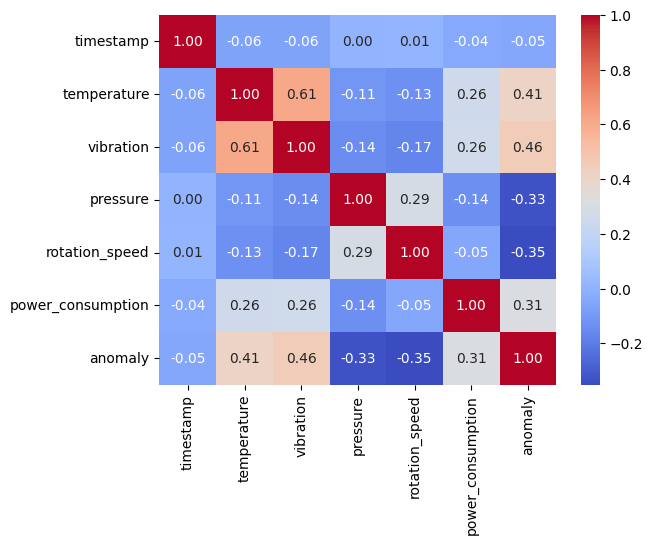

In [ ]:
sns.heatmap(df.corr(),cmap='coolwarm',fmt='.2f',annot=True)
# nearly all feature are nearly independent
# only temp and vibrationa are having more corrlation r=0.61

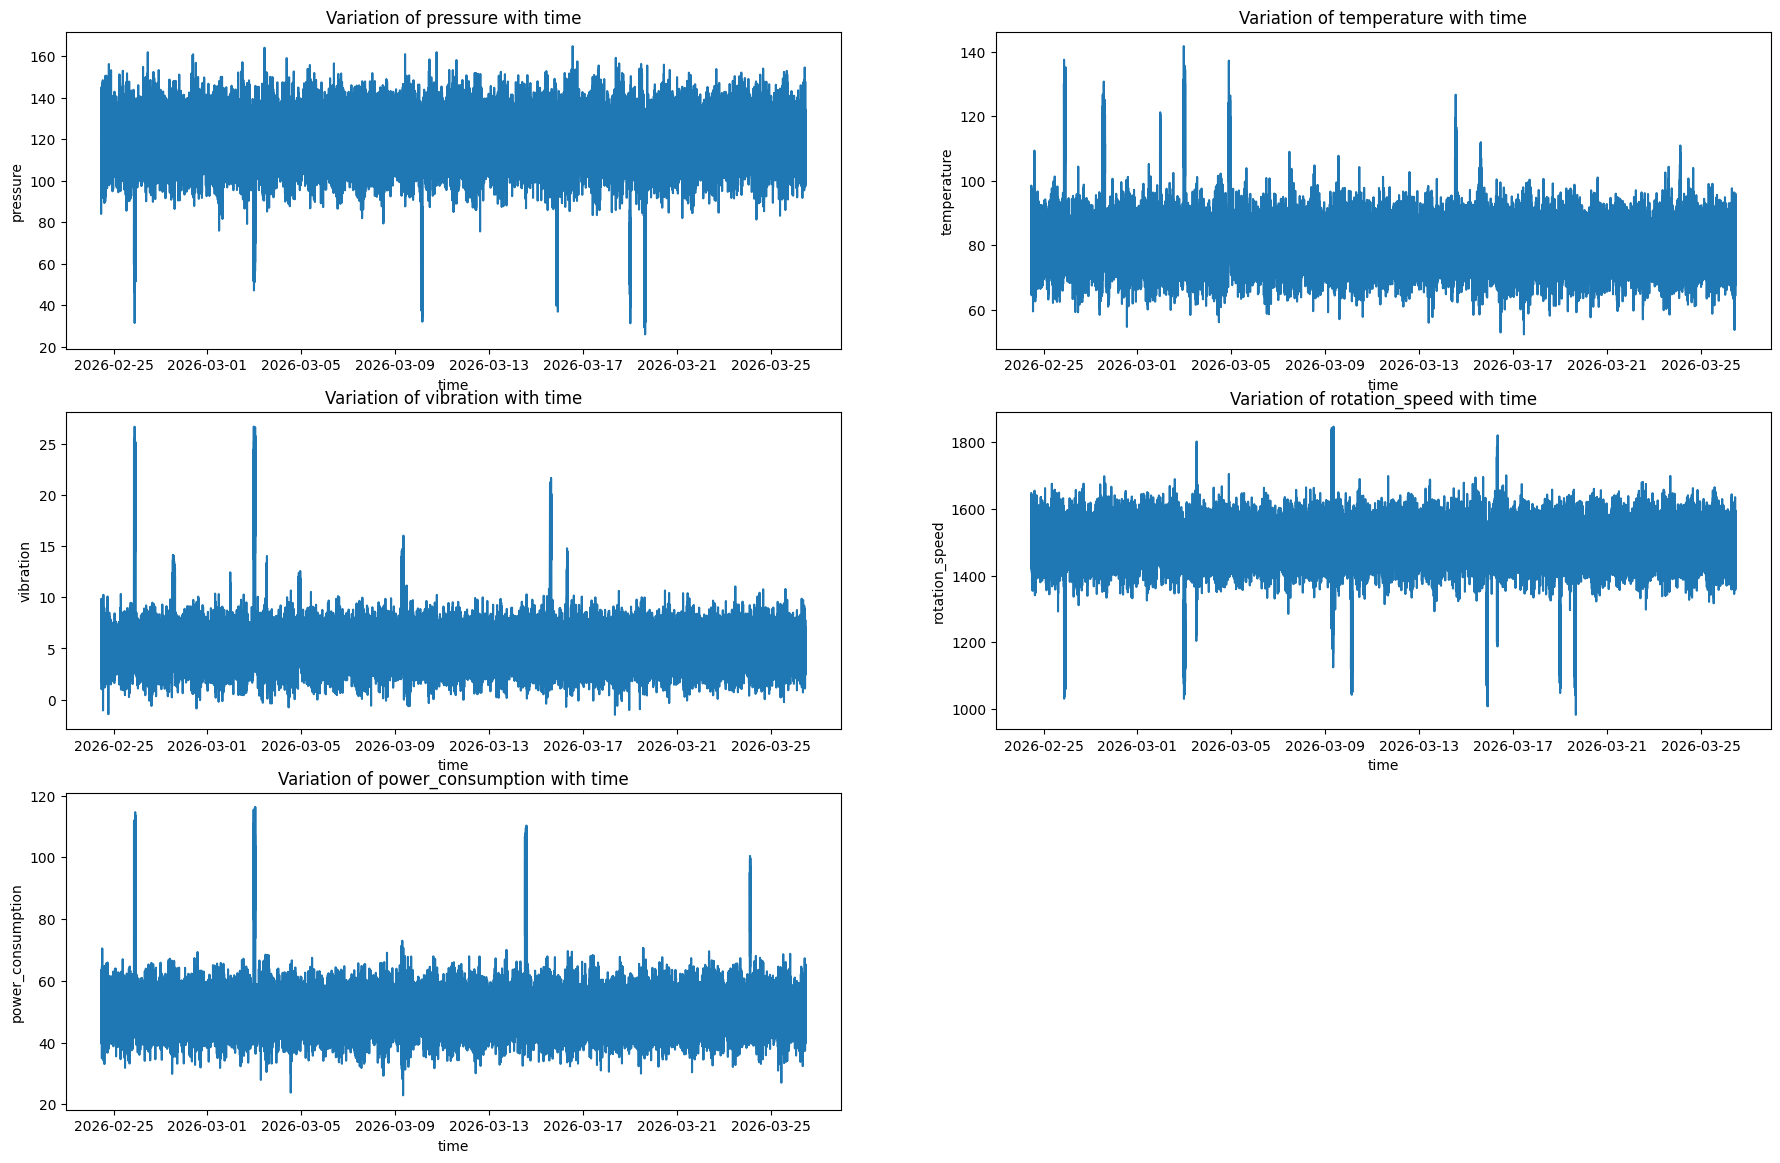

In [ ]:
plt.figure(figsize=(22,14))
for i,col in enumerate(columns):
  plt.subplot(3,2,i+1)
  sns.lineplot(x=df['timestamp'],y=df[col])
  plt.title(f"Variation of {col} with time")
  plt.xlabel("time")
  plt.ylabel(f"{col}")
plt.show()

# Even line plot shows distribution of time data and sensor correctly for outlier value are high or low. rest being in same range. avg being same or normal data

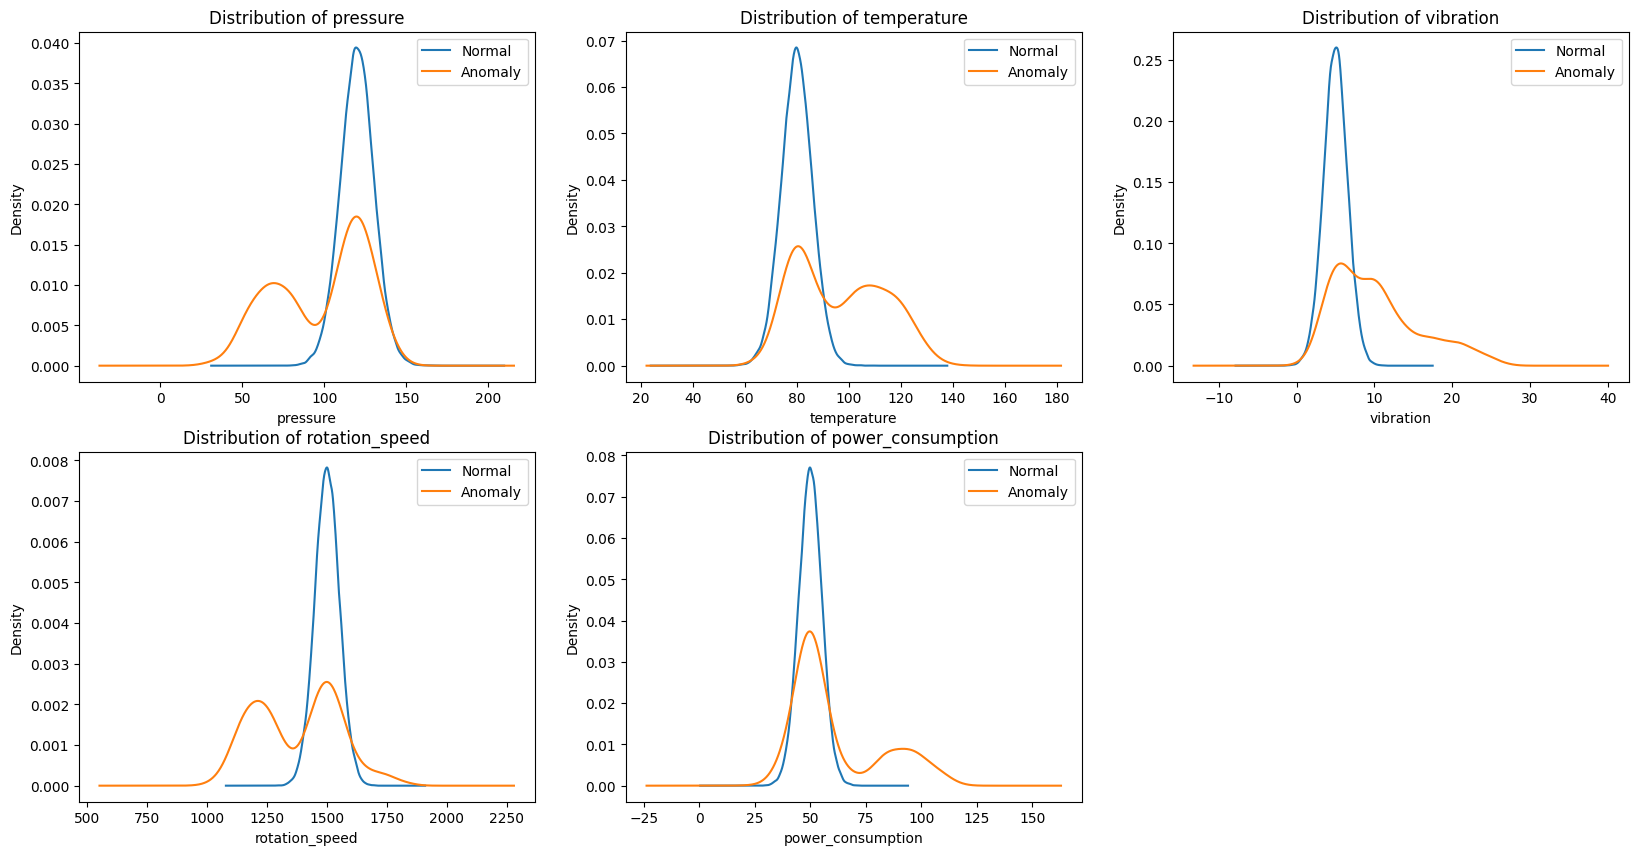

In [ ]:
# feature usefulness test

normal=df[df['anomaly']==0]
anomaly=df[df['anomaly']==1]

plt.figure(figsize=(20,10))
for i,col in enumerate(columns):
  plt.subplot(2,3,i+1)
  normal[col].plot.kde(label='Normal')
  anomaly[col].plot.kde(label='Anomaly')
  plt.title(f"Distribution of {col}")
  plt.xlabel(f"{col}")
  plt.ylabel("Density")
  plt.legend()
plt.show()

# KDE plots shows clear separation between 2 curves ie anomaly is rae compared to normal case.


In [ ]:
df.dtypes

,0
timestamp,datetime64[ns]
temperature,float64
vibration,float64
pressure,float64
rotation_speed,float64
power_consumption,float64
anomaly,int64


In [ ]:
df

,timestamp,temperature,vibration,pressure,rotation_speed,power_consumption,anomaly
0,2026-02-24 11:14:25.091904,83.32,5.18,118.47,1460.0,59.89,0
1,2026-02-24 11:15:25.091904,82.92,6.87,101.81,1541.0,53.48,0
2,2026-02-24 11:16:25.091904,89.40,7.77,117.47,1434.7,48.99,0
3,2026-02-24 11:17:25.091904,88.65,4.78,112.68,1421.3,54.37,0
4,2026-02-24 11:18:25.091904,81.74,6.57,135.94,1503.1,57.21,0
...,...,...,...,...,...,...,...
43195,2026-03-26 11:09:25.091904,84.10,5.38,126.03,1431.8,39.73,0
43196,2026-03-26 11:10:25.091904,84.95,4.01,110.03,1545.9,65.40,0
43197,2026-03-26 11:11:25.091904,78.41,2.42,106.23,1423.8,50.36,0
43198,2026-03-26 11:12:25.091904,73.57,4.48,129.55,1446.3,46.99,0


In [ ]:
# Time Lag features:

for col in columns:
  df[col+"_lag"]=df[col].diff()
  # drop 1st NAN row in every column
df = df.dropna().reset_index(drop=True)

In [ ]:
df.head()

,timestamp,temperature,vibration,pressure,rotation_speed,power_consumption,anomaly,pressure_lag,temperature_lag,vibration_lag,rotation_speed_lag,power_consumption_lag
0,2026-02-24 11:15:25.091904,82.92,6.87,101.81,1541.0,53.48,0,-16.66,-0.40,1.69,81.0,-6.41
1,2026-02-24 11:16:25.091904,89.40,7.77,117.47,1434.7,48.99,0,15.66,6.48,0.90,-106.3,-4.49
2,2026-02-24 11:17:25.091904,88.65,4.78,112.68,1421.3,54.37,0,-4.79,-0.75,-2.99,-13.4,5.38
3,2026-02-24 11:18:25.091904,81.74,6.57,135.94,1503.1,57.21,0,23.26,-6.91,1.79,81.8,2.84
4,2026-02-24 11:19:25.091904,82.30,6.85,126.70,1464.9,45.62,0,-9.24,0.56,0.28,-38.2,-11.59


<Axes: >

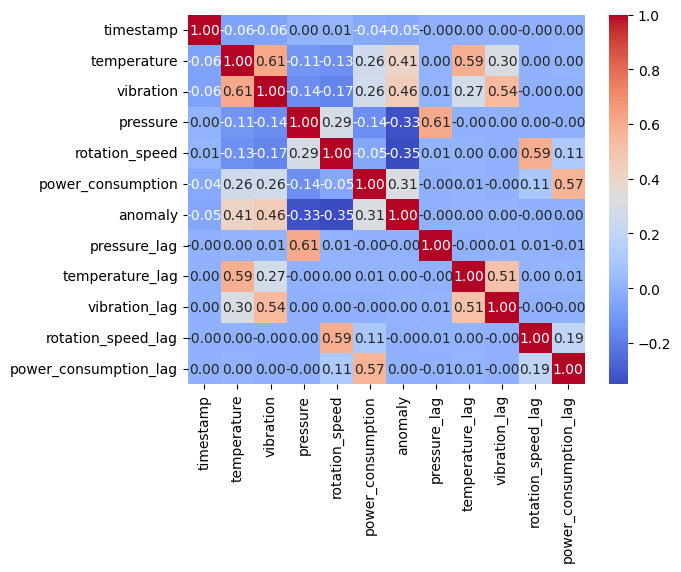

In [ ]:
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')

In [ ]:
df.shape

(43199, 12)

In [ ]:
# Now lets build model & tune hyperparmaters

#splitting data into train test validation

from sklearn.model_selection import train_test_split

x=df.drop(columns='anomaly')
y=df['anomaly']

n=len(df)
split=int(0.85*n)

x_train=x[:split]
y_train=y[:split]
x_test=x[split:]
y_test=y[split:]

In [ ]:
# download test data for inference

from google.colab import files

x_test.to_csv("x_test.csv",index=False)
y_test.to_csv("y_test.csv",index=False)

files.download("x_test.csv")
files.download("y_test.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df.dtypes

,0
timestamp,datetime64[ns]
temperature,float64
vibration,float64
pressure,float64
rotation_speed,float64
power_consumption,float64
anomaly,int64
pressure_lag,float64
temperature_lag,float64
vibration_lag,float64


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.4 MB/s eta 0:00:00


In [ ]:
# Building ML model Pipeline

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import warnings
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit,cross_val_score
import optuna
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,precision_score


optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler=optuna.samplers.TPESampler(seed=42)


num_feature=['pressure_lag','temperature_lag','vibration_lag','rotation_speed_lag','power_consumption_lag','power_consumption','rotation_speed','vibration','temperature','pressure']

preprocess=ColumnTransformer(transformers=[('normalization',StandardScaler(),num_feature)])


cv=TimeSeriesSplit(n_splits=5)

# Optuna Trial starting
# Logistic regression

def logistic_regression(trial):
  C=trial.suggest_float("C",0.0001,100,log=True)
  penalty=trial.suggest_categorical("penalty",['l1','l2'])
  solver=trial.suggest_categorical("solver",['saga','liblinear'])

  model=LogisticRegression(class_weight='balanced',random_state=42,C=C,penalty=penalty,solver=solver)
  pipe=Pipeline([('preprocess',preprocess),('classifier',model)])

  return cross_val_score(pipe,x_train,y_train,cv=cv,scoring='recall').mean()



def decision_tree(trial):
  max_depth=trial.suggest_int("max_depth",4,8)
  min_sample_split=trial.suggest_int("min_sample_split",2,10)
  min_sample_leaf=trial.suggest_int("min_sample_leaf",2,9)


  model=DecisionTreeClassifier(class_weight='balanced',random_state=42,min_samples_split=min_sample_split,min_samples_leaf=min_sample_leaf,max_depth=max_depth)
  pipe=Pipeline([('preprocess',preprocess),('classifier',model)])

  return cross_val_score(pipe,x_train,y_train,cv=cv,scoring='recall').mean()



def random_forest(trial):
  max_depth=trial.suggest_int("max_depth",2,10)
  min_sample_split=trial.suggest_int("min_sample_split",3,10)
  min_sample_leaf=trial.suggest_int("min_sample_leaf",3,9)
  n_extimators=trial.suggest_int("n_estimators",20,100)


  model=RandomForestClassifier(n_estimators=n_extimators,class_weight='balanced',random_state=42,min_samples_split=min_sample_split,min_samples_leaf=min_sample_leaf,max_depth=max_depth)
  pipe=Pipeline([('preprocess',preprocess),('classifier',model)])

  return cross_val_score(pipe,x_train,y_train,cv=cv,scoring='recall').mean()



def xg_boost_classifier(trial):
  max_depth=trial.suggest_int("max_depth",4,12)
  learning_rate=trial.suggest_float("learning_rate", 0.01, 0.4,log=True)
  n_estimators=trial.suggest_int("n_estimators",20,100)


  model=XGBClassifier(max_depth=max_depth,learning_rate=learning_rate,n_estimators=n_estimators,random_state=42,scale_pos_weight=28.6)
  pipe=Pipeline([('preprocess',preprocess),('classifier',model)])

  return cross_val_score(pipe,x_train,y_train,cv=cv,scoring='recall').mean()


study_lr = optuna.create_study(direction="maximize",sampler=sampler)
study_lr.optimize(logistic_regression, n_trials=50)

study_dt = optuna.create_study(direction="maximize",sampler=sampler)
study_dt.optimize(decision_tree, n_trials=50)

study_rf = optuna.create_study(direction="maximize",sampler=sampler)
study_rf.optimize(random_forest, n_trials=50)

study_xgb = optuna.create_study(direction="maximize",sampler=sampler)
study_xgb.optimize(xg_boost_classifier,n_trials=50)

print("Logistic Regression best score:", study_lr.best_value)
print("Logistic Regression best params:", study_lr.best_params)

print("Decision tree best score:", study_dt.best_value)
print("Decision tree best params:", study_dt.best_params)

print("Random Forest best score:", study_rf.best_value)
print("Random forest best params:", study_rf.best_params)

print("XGBoost best score:", study_xgb.best_value)
print("XGBoost best params:", study_xgb.best_params)




Logistic Regression best score: 0.7363602553199349
Logistic Regression best params: {'C': 0.0001016424204656213, 'penalty': 'l2', 'solver': 'liblinear'}
Decision tree best score: 0.7330641150971877
Decision tree best params: {'max_depth': 7, 'min_sample_split': 3, 'min_sample_leaf': 7}
Random Forest best score: 0.6639530564350883
Random forest best params: {'max_depth': 5, 'min_sample_split': 10, 'min_sample_leaf': 9, 'n_estimators': 29}
XGBoost best score: 0.6621476011562593
XGBoost best params: {'max_depth': 4, 'learning_rate': 0.11809672052587161, 'n_estimators': 51}


In [ ]:
# after final trainibg of best model

import pickle
best_model=XGBClassifier(max_depth=4,learning_rate=0.118,n_estimators=51,scale_pos_weight=28.6,random_state=42)

best_pipeline=Pipeline([('preprocess',preprocess),('classifier',best_model)])
best_pipeline.fit(x_train,y_train)

with open("best_model.pkl",'wb') as f:
 pickle.dump(best_pipeline,f)



In [ ]:
import os
print(os.listdir())

['.config', 'x_test.csv', 'y_test.csv', 'best_model.pkl', 'drive', 'sample_data']


In [ ]:
y_test.value_counts()

,count
anomaly,
0,6444
1,36


In [ ]:
#model evaluation

with open("best_model.pkl",'rb') as f:
  model=pickle.load(f)

from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,recall_score,precision_score,f1_score,roc_auc_score,roc_curve,precision_recall_curve
from IPython.display import display
threshold=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
summary_metrics=[]
for t in threshold:
 y_pred_proba=model.predict_proba(x_test)[:,1]
 y_pred=(y_pred_proba>=t).astype(int)
 pres=precision_score(y_test,y_pred)
 rec=recall_score(y_test,y_pred)
 f1=f1_score(y_test,y_pred)
 TN, FP, FN, TP=confusion_matrix(y_test,y_pred).ravel()
 summary_score={'threshold':t,'precision':pres,'recall':rec,'f1_score':f1,
                "confusion_matrix":[[TN,FP],
                                    [FN,TP]]}

 summary_metrics.append(summary_score)
best_result=pd.DataFrame(summary_metrics)
print("Summary Comparison Table across all metrics")
display(best_result)

Summary Comparison Table across all metrics


,threshold,precision,recall,f1_score,confusion_matrix
0,0.1,0.266667,1.0,0.421053,"[[6345, 99], [0, 36]]"
1,0.2,0.391304,1.0,0.562500,"[[6388, 56], [0, 36]]"
2,0.3,0.444444,1.0,0.615385,"[[6399, 45], [0, 36]]"
3,0.4,0.500000,1.0,0.666667,"[[6408, 36], [0, 36]]"
4,0.5,0.562500,1.0,0.720000,"[[6416, 28], [0, 36]]"
5,0.6,0.620690,1.0,0.765957,"[[6422, 22], [0, 36]]"
6,0.7,0.679245,1.0,0.808989,"[[6427, 17], [0, 36]]"
7,0.8,0.750000,1.0,0.857143,"[[6432, 12], [0, 36]]"
8,0.9,0.857143,1.0,0.923077,"[[6438, 6], [0, 36]]"


In [ ]:
# Threshold  increases means model triggers maintainace using AI late ( may be just eg at 15 % degradion) while lower threshold trigger early maintaaince ieeg  55% degradation ie too dangerous

# FN- missed anomaly =machin e breakdown and FP= unbessary check

# find threshold index at which pred prob of being anmolay > threshold value chosen threshold=0.5,0.6,0.7
threshold=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
import numpy as np
trig_array=[]
for t in threshold:
  y_pred_prob=model.predict_proba(x_test)[:,1]
  y_pred=(y_pred_proba>=t).astype(int)
  trigger_idx=np.argmax(y_pred_prob>t)
  trig_array.append(trigger_idx.tolist())
thrigg_dict={'threshold':threshold,'trigger_idx':trig_array}
thrigg_df=pd.DataFrame(thrigg_dict)
display(thrigg_df)


,threshold,trigger_idx
0,0.1,265
1,0.2,265
2,0.3,265
3,0.4,860
4,0.5,860
5,0.6,860
6,0.7,860
7,0.8,860


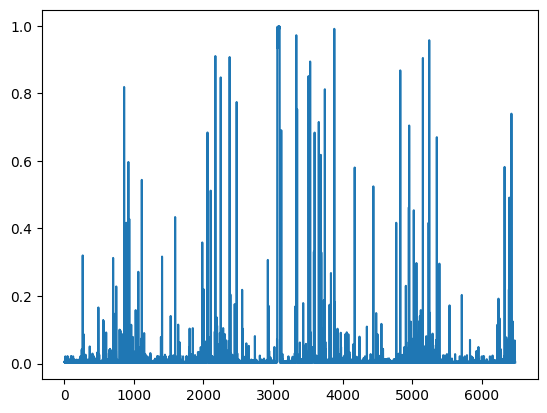

In [ ]:
plt.plot(y_pred_prob)
# no gradual decay is seen but anomalies is tehre for 1 bad sensor data . This is random fault not progressive degradation


In [ ]:
cum_prob=np.cumsum(y_pred_prob)
deg=pd.Series(cum_prob)
deg_pct=(deg/deg.max())*100 # convert all prob in range 0 to 100 ie show degradation increases from 0 to 100

In [ ]:
print(deg_pct)

0         0.004623
1         0.007790
2         0.010957
3         0.015910
4         0.019376
           ...    
6475     99.982826
6476     99.990875
6477     99.994263
6478     99.997131
6479    100.000000
Length: 6480, dtype: float32


Text(0, 0.5, 'degradation%')

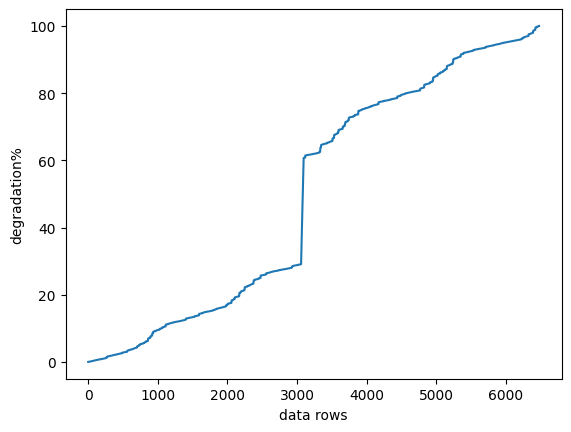

In [ ]:
plt.plot(deg_pct)
plt.xlabel("data rows")
plt.ylabel("degradation%")


In [ ]:
trg_idx=np.argmax(deg_pct>49)
trg_deg=deg_pct[trg_idx]
print(f"trigger index is {trg_idx}") # at 3000 index degradtion suddenly jump froms 30 to 60% . That is point to be noted


trigger index is 3082


In [ ]:
x_test

,timestamp,temperature,vibration,pressure,rotation_speed,power_consumption,pressure_lag,temperature_lag,vibration_lag,rotation_speed_lag,power_consumption_lag
36719,2026-03-21 23:14:25.091904,84.31,6.55,135.56,1503.3,52.15,33.46,-1.05,0.77,36.6,3.01
36720,2026-03-21 23:15:25.091904,81.85,5.05,134.87,1483.4,47.61,-0.69,-2.46,-1.50,-19.9,-4.54
36721,2026-03-21 23:16:25.091904,80.71,3.90,121.30,1511.5,52.42,-13.57,-1.14,-1.15,28.1,4.81
36722,2026-03-21 23:17:25.091904,76.08,6.74,122.25,1397.3,45.11,0.95,-4.63,2.84,-114.2,-7.31
36723,2026-03-21 23:18:25.091904,78.40,4.99,122.50,1472.1,42.00,0.25,2.32,-1.75,74.8,-3.11
...,...,...,...,...,...,...,...,...,...,...,...
43194,2026-03-26 11:09:25.091904,84.10,5.38,126.03,1431.8,39.73,27.89,-0.16,0.55,-48.2,-13.35
43195,2026-03-26 11:10:25.091904,84.95,4.01,110.03,1545.9,65.40,-16.00,0.85,-1.37,114.1,25.67
43196,2026-03-26 11:11:25.091904,78.41,2.42,106.23,1423.8,50.36,-3.80,-6.54,-1.59,-122.1,-15.04
43197,2026-03-26 11:12:25.091904,73.57,4.48,129.55,1446.3,46.99,23.32,-4.84,2.06,22.5,-3.37


In [ ]:
timestamps = pd.to_datetime(x_test['timestamp'])

print(f"trigger_idx  : {trg_idx}")
print(f"trigger_deg  : {trg_deg:.1f}%")
print(f"trigger_time : {timestamps.iloc[trg_idx]}")
print(f"total rows   : {len(deg_pct)}")

trigger_idx  : 3082
trigger_deg  : 49.2%
trigger_time : 2026-03-24 02:36:25.091904
total rows   : 6480


Text(3182, 51.225799560546875, 'AI Triggered | Row 3082 | 49.2%')

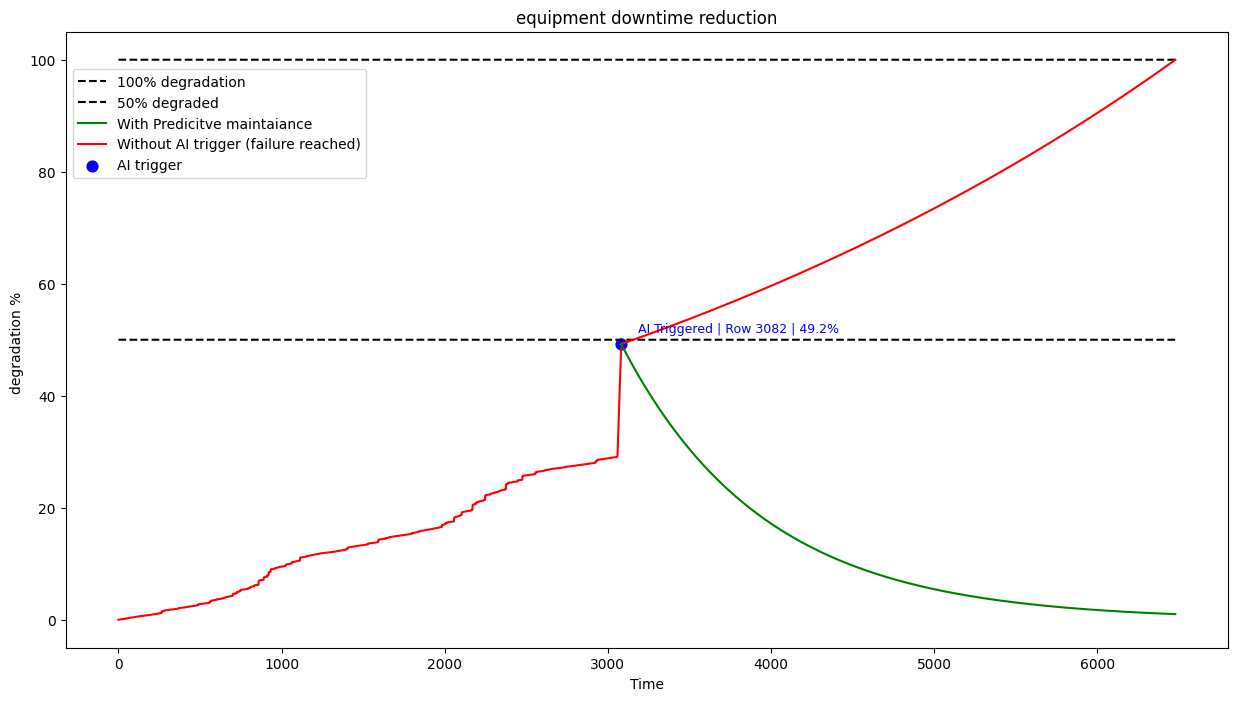

In [71]:
time_axis=np.arange(len(x_test))
degradation_time_length=len(x_test)-trg_idx  # time from failure start ie 50% deg to 100 %
fail_steps=np.arange(degradation_time_length)
recovery_steps=fail_steps # same for reovery ie mianitaiance is triggered at just below 50% ie 49.2%
k_fail=(1/degradation_time_length) *(np.log(100/trg_deg))
k_recovery=(-1/len(recovery_steps))*(np.log(1/trg_deg))  # assume 1 % is degradtion rate after recovery ie maintaaince

# all recovery and degradtion curve assumed to be exponential ie mathemical model ie y=Ae^kt k=+ve for growth and neg for recovery
fail_y=trg_deg*np.exp(k_fail*fail_steps)
y_degradation=np.clip(fail_y,0,100)
x_degradation=time_axis[trg_idx:]
recovery_y=trg_deg*np.exp(-k_recovery*recovery_steps)
y_recovery=np.clip(recovery_y,0,100)
x_recovery=x_degradation

plt.figure(figsize=(15,8))
plt.plot(time_axis,np.full(len(x_test),100),color='black',linestyle='dashed',label='100% degradation') # create aref line at y=100
plt.plot(time_axis,np.full(len(x_test),50),color='black',linestyle='dashed',label='50% degraded') # create a 50% degradtion line
plt.plot(x_degradation,y_degradation,color='red')
plt.plot(x_recovery,y_recovery,color='green',label='With Predicitve maintaiance')
plt.plot(time_axis[:trg_idx],deg_pct[:trg_idx],color='red',label='Without AI trigger (failure reached)')
plt.scatter(trg_idx,trg_deg,color='blue',s=60,label='AI trigger')
plt.xlabel("Time")
plt.ylabel("degradation % ")
plt.title("equipment downtime reduction")
plt.legend(loc='upper left',bbox_to_anchor=(0,0.95))
plt.text(trg_idx+100, trg_deg+2,   # annote the trigger point
         f'AI Triggered | Row {trg_idx} | {trg_deg:.1f}%',
         color='blue', fontsize=9)


